# (1) Invariant curvature analysis: MassiveLion vs. Lion

device = ```cuda:0```

In [1]:
# HIDE CODE


import os, pathlib
from IPython.display import display

# tmp & extras dir
_jb_dir = pathlib.Path(os.environ['HOME'])
_jb_dir /= 'Dropbox/git/jb-progress-2026'
extras_dir = _jb_dir / '_extras'
fig_base_dir = _jb_dir / 'figs'
tmp_dir = _jb_dir / 'tmp'

from gra.utils.plotting import *

# warnings, tqdm, & style
warnings.filterwarnings('ignore', category=DeprecationWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
from rich.jupyter import print
%matplotlib inline
set_style()

In [2]:
## HIDE CODE


from gra.experiments.vision.models import WideResNet, ResNet18, ConvNet, MLP


def _ckpt_arg(ckpt, key, default=None):
    args = ckpt.get("args", {})
    return args.get(key, default) if isinstance(args, dict) else getattr(args, key, default)

def _clean_state_dict(sd):
    return {
        k.removeprefix("_orig_mod."): v
        for k, v in sd.items()
    }

def ckpt_to_vision_model(ckpt, device="cpu"):
    dataset = str(_ckpt_arg(ckpt, "dataset", "CIFAR10"))
    model_name = _ckpt_arg(ckpt, "model", "resnet")
    num_classes = 1000 if "imagenet" in dataset.lower() else 10

    model_cls = {
        "resnet": ResNet18,
        "wrn": WideResNet,
        "convnet": ConvNet,
        "mlp": MLP,
    }[model_name]

    model = model_cls(num_classes=num_classes).to(device)
    model.load_state_dict(_clean_state_dict(ckpt["model"]), strict=True)
    model.eval()
    return model

In [3]:
from gra.diagnostics.invariant_curvature_metrics import (
    DEFAULT_PERTURB_SCALES,
    display_probe_interpretation,
    filter_normalized_adversarial_sharpness,
    filter_normalized_adversarial_kl,
    filter_normalized_thermal_susceptibility,
    filter_normalized_fisher_normal_modes,
    plot_scale_sweep,
    plot_normal_mode_bars,
    compare_to_reference,
)

import pandas as pd
from gra.utils.dataset import make_dataloader

In [4]:
device_idx = 0
device = f'cuda:{device_idx}'

print(f"device: {device}  ———  host: {os.uname().nodename}")

device: cuda:0  ———  host: chewie

## step 0 — load stuff

### load runs

In [5]:
%%time


from gra.experiments.common.checkpointing import resolve_resume_source, load_checkpoint

run_paths = {
    "m_lion_b1=0.7": "pal-lab/GRA-CIFAR10/60u46yf2",
    "m_lion_b1=0.5": "pal-lab/GRA-CIFAR10/wldu4pzr",
    "m_lion_b1=0.3": "pal-lab/GRA-CIFAR10/i9y0mti2",
    "m_lion_b1=0.1": "pal-lab/GRA-CIFAR10/e1tytqhy",
}

sources = {k: resolve_resume_source(v) for k, v in run_paths.items()}
ckpts = {
    k: load_checkpoint(src.checkpoint_path, map_location="cpu")
    for k, src in sources.items()
}

models = {k: ckpt_to_vision_model(ch) for k, ch in ckpts.items()}

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hadi/.netrc.


CPU times: user 1.32 s, sys: 284 ms, total: 1.6 s
Wall time: 4.65 s


### Load data

In [6]:
train_loader, val_loader = make_dataloader(
    dataset="CIFAR10",
    batch_size=384,
    device=device,
)

loader = val_loader

## step 1 — run the big loop

In [7]:
%%time


shared = {
    "device": device,
    "max_batches": 20,
    "perturb_scales": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1],
}

adv_ce_rows = []
adv_kl_rows = []
thermal_rows = []
normal_mode_rows = []

for label, model in tqdm(models.items()):
    for perturb_scale in shared["perturb_scales"]:
        out = filter_normalized_adversarial_sharpness(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            ascent_steps=10,
            max_batches=shared["max_batches"],
        )
        adv_ce_rows.append({"label": label, **out})

        out = filter_normalized_adversarial_kl(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            ascent_steps=10,
            max_batches=shared["max_batches"],
        )
        adv_kl_rows.append({"label": label, **out})

        out = filter_normalized_thermal_susceptibility(
            model,
            loader,
            device=shared["device"],
            perturb_scale=perturb_scale,
            samples=30,
            max_batches=shared["max_batches"],
        )
        thermal_rows.append({"label": label, **out})

    out = filter_normalized_fisher_normal_modes(
        model,
        loader,
        device=shared["device"],
        max_batches=10,
        lanczos_steps=12,
        random_probes=8,
    )
    normal_mode_rows.append({"label": label, **out})

adv_ce_df = pd.DataFrame(adv_ce_rows)
adv_kl_df = pd.DataFrame(adv_kl_rows)
thermal_df = pd.DataFrame(thermal_rows)
normal_modes_df = pd.DataFrame(normal_mode_rows)


  0%|          | 0/4 [00:00<?, ?it/s]

CPU times: user 11min 23s, sys: 7min 29s, total: 18min 52s
Wall time: 17min 56s


## step 2 — inspect / visualize

### plots

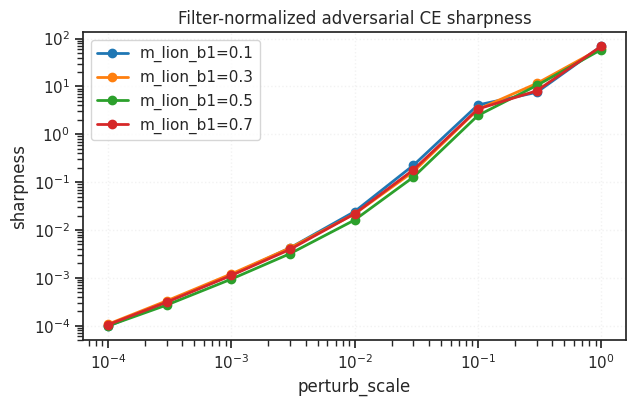

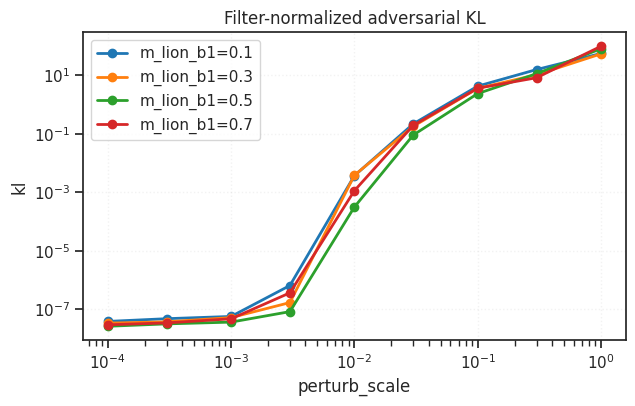

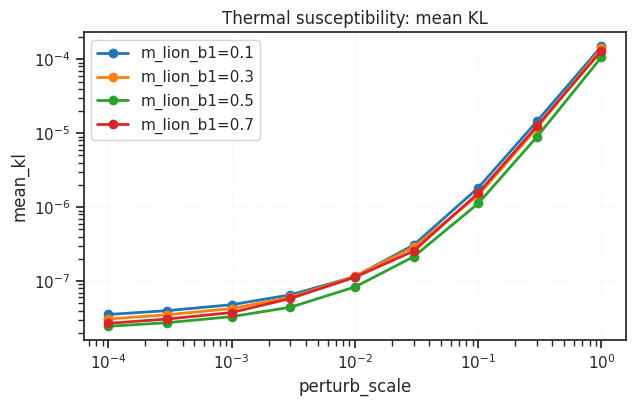

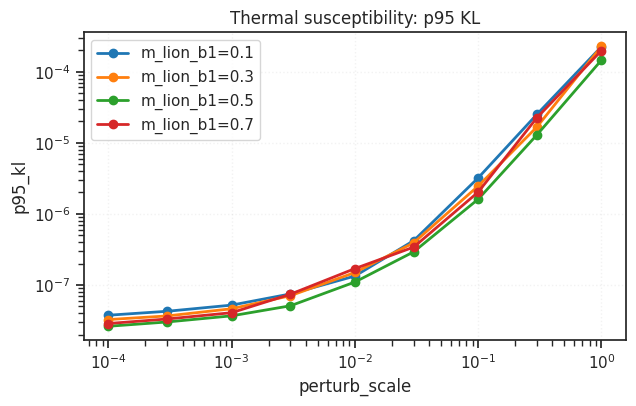

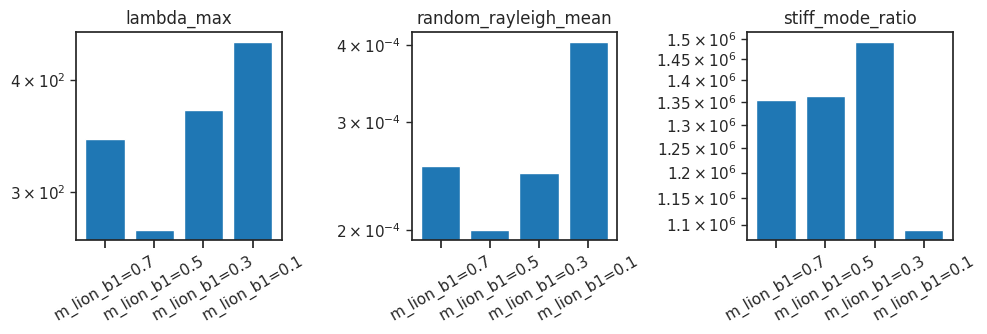

In [8]:
plot_scale_sweep(adv_ce_df, "sharpness", title="Filter-normalized adversarial CE sharpness")
plot_scale_sweep(adv_kl_df, "kl", title="Filter-normalized adversarial KL")
plot_scale_sweep(thermal_df, "mean_kl", title="Thermal susceptibility: mean KL")
plot_scale_sweep(thermal_df, "p95_kl", title="Thermal susceptibility: p95 KL")

plot_normal_mode_bars(normal_modes_df);

### relative to m_lion

In [11]:
# Useful ratio tables against MassiveLion.
adv_ce_vs_mlion = compare_to_reference(adv_ce_df, "sharpness", reference_label="m_lion_b1=0.7")
adv_kl_vs_mlion = compare_to_reference(adv_kl_df, "kl", reference_label="m_lion_b1=0.7")
thermal_vs_mlion = compare_to_reference(thermal_df, "mean_kl", reference_label="m_lion_b1=0.7")

display(adv_ce_vs_mlion)
display(adv_kl_vs_mlion)
display(thermal_vs_mlion)


label,perturb_scale,m_lion_b1=0.1,m_lion_b1=0.3,m_lion_b1=0.5,m_lion_b1=0.7,m_lion_b1=0.1_over_m_lion_b1=0.7,m_lion_b1=0.1_minus_m_lion_b1=0.7,m_lion_b1=0.3_over_m_lion_b1=0.7,m_lion_b1=0.3_minus_m_lion_b1=0.7,m_lion_b1=0.5_over_m_lion_b1=0.7,m_lion_b1=0.5_minus_m_lion_b1=0.7,m_lion_b1=0.7_over_m_lion_b1=0.7,m_lion_b1=0.7_minus_m_lion_b1=0.7
0,0.0001,0.000097,0.000108,0.000099,0.000105,0.929092,-0.000007,1.027206,0.000003,0.945256,-0.000006,1.0,0.0
1,0.0003,0.000318,0.000332,0.000271,0.000312,1.018364,0.000006,1.064825,0.000020,0.868906,-0.000041,1.0,0.0
2,0.0010,0.001148,0.001211,0.000941,0.001124,1.021364,0.000024,1.077049,0.000087,0.837470,-0.000183,1.0,0.0
3,0.0030,0.004246,0.004232,0.003212,0.003944,1.076487,0.000302,1.072805,0.000287,0.814319,-0.000732,1.0,0.0
4,0.0100,0.024262,0.021681,0.016169,0.021853,1.110231,0.002409,0.992151,-0.000172,0.739918,-0.005684,1.0,0.0
5,0.0300,0.225696,0.165920,0.127768,0.181366,1.244427,0.044331,0.914837,-0.015446,0.704479,-0.053597,1.0,0.0
6,0.1000,4.100413,3.321923,2.472852,3.371351,1.216252,0.729062,0.985339,-0.049428,0.733490,-0.898499,1.0,0.0
7,0.3000,7.528735,11.537738,10.465729,8.099920,0.929483,-0.571185,1.424426,3.437818,1.292078,2.365809,1.0,0.0
8,1.0000,69.002134,63.192935,58.925291,69.028096,0.999624,-0.025962,0.915467,-5.835161,0.853642,-10.102805,1.0,0.0


label,perturb_scale,m_lion_b1=0.1,m_lion_b1=0.3,m_lion_b1=0.5,m_lion_b1=0.7,m_lion_b1=0.1_over_m_lion_b1=0.7,m_lion_b1=0.1_minus_m_lion_b1=0.7,m_lion_b1=0.3_over_m_lion_b1=0.7,m_lion_b1=0.3_minus_m_lion_b1=0.7,m_lion_b1=0.5_over_m_lion_b1=0.7,m_lion_b1=0.5_minus_m_lion_b1=0.7,m_lion_b1=0.7_over_m_lion_b1=0.7,m_lion_b1=0.7_minus_m_lion_b1=0.7
0,0.0001,3.787690e-08,3.319603e-08,2.583648e-08,2.901612e-08,1.305374,8.860783e-09,1.144055,4.179912e-09,0.890418,-3.179636e-09,1.0,0.0
1,0.0003,4.699761e-08,3.667364e-08,3.122076e-08,3.370916e-08,1.394209,1.328845e-08,1.087943,2.964489e-09,0.926181,-2.488393e-09,1.0,0.0
2,0.0010,5.603981e-08,5.129916e-08,3.589668e-08,4.652353e-08,1.204548,9.516276e-09,1.102650,4.775629e-09,0.771581,-1.062686e-08,1.0,0.0
3,0.0030,6.412376e-07,1.672221e-07,8.194963e-08,3.599496e-07,1.781465,2.812880e-07,0.464571,-1.927275e-07,0.227670,-2.779999e-07,1.0,0.0
4,0.0100,3.656943e-03,3.760953e-03,3.094334e-04,1.119362e-03,3.266988,2.537580e-03,3.359907,2.641591e-03,0.276437,-8.099289e-04,1.0,0.0
5,0.0300,2.159522e-01,1.776410e-01,8.963648e-02,1.910509e-01,1.130339,2.490131e-02,0.929810,-1.340989e-02,0.469176,-1.014144e-01,1.0,0.0
6,0.1000,4.223087e+00,3.538892e+00,2.350057e+00,3.585324e+00,1.177881,6.377625e-01,0.987049,-4.643215e-02,0.655466,-1.235267e+00,1.0,0.0
7,0.3000,1.556812e+01,1.031287e+01,1.125572e+01,8.174856e+00,1.904390,7.393260e+00,1.261535,2.138012e+00,1.376871,3.080867e+00,1.0,0.0
8,1.0000,5.536095e+01,5.362243e+01,8.039540e+01,9.747874e+01,0.567928,-4.211779e+01,0.550094,-4.385631e+01,0.824748,-1.708334e+01,1.0,0.0


label,perturb_scale,m_lion_b1=0.1,m_lion_b1=0.3,m_lion_b1=0.5,m_lion_b1=0.7,m_lion_b1=0.1_over_m_lion_b1=0.7,m_lion_b1=0.1_minus_m_lion_b1=0.7,m_lion_b1=0.3_over_m_lion_b1=0.7,m_lion_b1=0.3_minus_m_lion_b1=0.7,m_lion_b1=0.5_over_m_lion_b1=0.7,m_lion_b1=0.5_minus_m_lion_b1=0.7,m_lion_b1=0.7_over_m_lion_b1=0.7,m_lion_b1=0.7_minus_m_lion_b1=0.7
0,0.0001,3.534667e-08,3.072212e-08,2.448054e-08,2.686454e-08,1.315737,8.482132e-09,1.143594,3.857583e-09,0.911258,-2.384002e-09,1.0,0.0
1,0.0003,3.982404e-08,3.503500e-08,2.737756e-08,3.065350e-08,1.299168,9.170535e-09,1.142936,4.381494e-09,0.893130,-3.275940e-09,1.0,0.0
2,0.0010,4.794374e-08,4.255188e-08,3.306942e-08,3.756002e-08,1.276457,1.038372e-08,1.132904,4.991861e-09,0.880442,-4.490602e-09,1.0,0.0
3,0.0030,6.512190e-08,6.031296e-08,4.434651e-08,5.816230e-08,1.119658,6.959599e-09,1.036977,2.150660e-09,0.762461,-1.381579e-08,1.0,0.0
4,0.0100,1.151123e-07,1.159062e-07,8.325856e-08,1.127580e-07,1.020880,2.354348e-09,1.027920,3.148159e-09,0.738383,-2.949944e-08,1.0,0.0
5,0.0300,3.079073e-07,2.875536e-07,2.141019e-07,2.548305e-07,1.208283,5.307680e-08,1.128411,3.272305e-08,0.840174,-4.072858e-08,1.0,0.0
6,0.1000,1.826987e-06,1.445393e-06,1.121193e-06,1.548123e-06,1.180130,2.788638e-07,0.933642,-1.027307e-07,0.724227,-4.269302e-07,1.0,0.0
7,0.3000,1.454508e-05,1.181326e-05,8.959567e-06,1.248312e-05,1.165180,2.061960e-06,0.946339,-6.698610e-07,0.717734,-3.523557e-06,1.0,0.0
8,1.0000,1.498181e-04,1.413250e-04,1.069587e-04,1.304222e-04,1.148716,1.939593e-05,1.083596,1.090283e-05,0.820096,-2.346342e-05,1.0,0.0


### results df

In [12]:
display(adv_ce_df)
display(adv_kl_df)
display(thermal_df)
display(normal_modes_df)

,label,perturb_scale,base_loss,base_acc,sharp_loss,sharp_acc,sharpness,relative_sharpness,ascent_steps,max_batches
0,m_lion_b1=0.7,0.0001,0.249568,0.932813,0.249673,0.932682,0.000105,0.000420,10,20
1,m_lion_b1=0.7,0.0003,0.249568,0.932813,0.249881,0.932682,0.000312,0.001251,10,20
2,m_lion_b1=0.7,0.0010,0.249568,0.932813,0.250693,0.932161,0.001124,0.004504,10,20
3,m_lion_b1=0.7,0.0030,0.249568,0.932813,0.253513,0.932161,0.003944,0.015805,10,20
4,m_lion_b1=0.7,0.0100,0.249568,0.932813,0.271421,0.927083,0.021853,0.087563,10,20
5,m_lion_b1=0.7,0.0300,0.249568,0.932813,0.430934,0.888281,0.181366,0.726717,10,20
6,m_lion_b1=0.7,0.1000,0.249568,0.932813,3.620920,0.286719,3.371351,13.508727,10,20
7,m_lion_b1=0.7,0.3000,0.249568,0.932813,8.349488,0.099740,8.099920,32.455712,10,20
8,m_lion_b1=0.7,1.0000,0.249568,0.932813,69.277665,0.103125,69.028096,276.589901,10,20
9,m_lion_b1=0.5,0.0001,0.251316,0.928516,0.251415,0.928385,0.000099,0.000394,10,20


,label,perturb_scale,base_loss,base_acc,pert_loss,pert_acc,kl,ascent_steps,max_batches
0,m_lion_b1=0.7,0.0001,0.249568,0.932813,0.249572,0.932813,2.901612e-08,10,20
1,m_lion_b1=0.7,0.0003,0.249568,0.932813,0.249567,0.932813,3.370916e-08,10,20
2,m_lion_b1=0.7,0.0010,0.249568,0.932813,0.249570,0.932813,4.652353e-08,10,20
3,m_lion_b1=0.7,0.0030,0.249568,0.932813,0.249593,0.932813,3.599496e-07,10,20
4,m_lion_b1=0.7,0.0100,0.249568,0.932813,0.249261,0.933073,1.119362e-03,10,20
5,m_lion_b1=0.7,0.0300,0.249568,0.932813,0.429645,0.889974,1.910509e-01,10,20
6,m_lion_b1=0.7,0.1000,0.249568,0.932813,3.829309,0.254036,3.585324e+00,10,20
7,m_lion_b1=0.7,0.3000,0.249568,0.932813,8.412753,0.099740,8.174856e+00,10,20
8,m_lion_b1=0.7,1.0000,0.249568,0.932813,97.546361,0.101172,9.747874e+01,10,20
9,m_lion_b1=0.5,0.0001,0.251316,0.928516,0.251321,0.928516,2.583648e-08,10,20


,label,perturb_scale,base_loss,base_acc,mean_kl,std_kl,p95_kl,mean_loss,mean_loss_increase,p95_loss_increase,mean_acc,worst_acc,samples,max_batches
0,m_lion_b1=0.7,0.0001,0.249568,0.932813,2.686454e-08,1.321493e-09,2.859834e-08,0.249568,-3.178914e-08,3.335873e-06,0.932812,0.932813,30,20
1,m_lion_b1=0.7,0.0003,0.249568,0.932813,3.065350e-08,1.722555e-09,3.312516e-08,0.249568,7.251898e-08,2.963344e-06,0.932812,0.932813,30,20
2,m_lion_b1=0.7,0.0010,0.249568,0.932813,3.756002e-08,2.241892e-09,4.061257e-08,0.249569,7.877747e-07,5.466739e-06,0.932812,0.932813,30,20
3,m_lion_b1=0.7,0.0030,0.249568,0.932813,5.816230e-08,7.770590e-09,7.394442e-08,0.249571,2.441804e-06,7.970134e-06,0.932812,0.932813,30,20
4,m_lion_b1=0.7,0.0100,0.249568,0.932813,1.127580e-07,2.789042e-08,1.695821e-07,0.249574,5.258123e-06,1.331965e-05,0.932812,0.932813,30,20
5,m_lion_b1=0.7,0.0300,0.249568,0.932813,2.548305e-07,4.776838e-08,3.405657e-07,0.249577,8.342663e-06,2.777378e-05,0.932786,0.932682,30,20
6,m_lion_b1=0.7,0.1000,0.249568,0.932813,1.548123e-06,6.309508e-07,2.024522e-06,0.249584,1.582305e-05,7.416109e-05,0.932760,0.932682,30,20
7,m_lion_b1=0.7,0.3000,0.249568,0.932813,1.248312e-05,4.985669e-06,2.261342e-05,0.249574,5.407135e-06,1.808534e-04,0.932787,0.932552,30,20
8,m_lion_b1=0.7,1.0000,0.249568,0.932813,1.304222e-04,3.855836e-05,1.985829e-04,0.249736,1.674722e-04,7.096062e-04,0.932504,0.931641,30,20
9,m_lion_b1=0.5,0.0001,0.251316,0.928516,2.448054e-08,1.171772e-09,2.615547e-08,0.251319,2.633532e-06,5.375346e-06,0.928516,0.928516,30,20


,label,base_loss,base_acc,n_examples,n_params,lambda_max,top_eigs,random_rayleigh_mean,random_rayleigh_std,stiff_mode_ratio,...,random_probes,max_batches,top_eig_1,top_eig_2,top_eig_3,top_eig_4,top_eig_5,top_eig_6,top_eig_7,top_eig_8
0,m_lion_b1=0.7,0.245112,0.936458,3840,11173962,343.906952,"[343.9069519042969, 304.0756530761719, 270.462...",0.000254,0.000077,1.355215e+06,...,8,10,343.906952,304.075653,270.462769,233.595474,200.121933,155.476868,131.597076,85.869461
1,m_lion_b1=0.5,0.254487,0.925521,3840,11173962,272.311340,"[272.31134033203125, 214.89698791503906, 193.7...",0.000200,0.000073,1.363017e+06,...,8,10,272.311340,214.896988,193.759109,154.994766,133.636795,116.308167,95.587830,74.815178
2,m_lion_b1=0.3,0.264014,0.922917,3840,11173962,369.979950,"[369.9799499511719, 304.2317810058594, 253.367...",0.000248,0.000071,1.493343e+06,...,8,10,369.979950,304.231781,253.367355,246.701675,173.035141,141.682922,97.716682,86.584091
3,m_lion_b1=0.1,0.269664,0.926302,3840,11173962,440.943726,"[440.9437255859375, 393.0061340332031, 324.299...",0.000405,0.000166,1.089357e+06,...,8,10,440.943726,393.006134,324.299835,315.772217,243.612930,196.119095,162.395004,101.557968
